# A combined raster + vector GIS scene

The payoff: **raster and vector data in one 3-D scene**. The Rhine flow-accumulation raster (`DEM5km_Rhine_burned_acc.tif`, EPSG:4647) is **reprojected through pyramids** to the vectors' CRS (EPSG:3035), draped as a surface, and overlaid with the river network and gauges. All GIS work (reproject, coordinates) stays in pyramids; PyVista only renders.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import geopandas as gpd

pv.OFF_SCREEN = True  # headless: scenes render to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title='', view='iso', parallel=False, zoom=None):
    """Point the camera at a named view, then screenshot the scene inline (asserts it isn't blank).

    view: 'iso' (oblique), 'top' (map/plan view), 'front', 'side', or an (azimuth, elevation) offset tuple
    applied on top of the isometric view. parallel=True uses an orthographic camera (true map scale).
    """
    p = scene.plotter
    if parallel:
        p.enable_parallel_projection()
    if view == 'top':
        p.view_xy()
    elif view == 'front':
        p.view_xz()
    elif view == 'side':
        p.view_yz()
    elif isinstance(view, tuple):
        p.view_isometric(); p.camera.azimuth += view[0]; p.camera.elevation += view[1]
    else:
        p.view_isometric()
    if zoom:
        p.camera.zoom(zoom)
    p.render()
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} of the scene differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

def lines_to_tubes(gdf, radius, z=0.0):
    """Turn a (Multi)LineString GeoDataFrame into a single tube mesh at height z (only coords read)."""
    tubes = []
    for geom in gdf.geometry:
        for part in (geom.geoms if geom.geom_type.startswith('Multi') else [geom]):
            xy = np.asarray(part.coords, dtype='float64')
            if len(xy) < 2:
                continue
            pts = np.column_stack([xy[:, 0], xy[:, 1], np.full(len(xy), z)])
            tubes.append(pv.lines_from_points(pts).tube(radius=radius))
    return pv.MultiBlock(tubes).combine()

def lollipops(gdf, value_col, height, radius):
    """Build vertical stems (a tube mesh) + top points (xyz, values) for a 3-D lollipop chart of point data."""
    x = gdf.geometry.x.to_numpy(); y = gdf.geometry.y.to_numpy()
    v = gdf[value_col].to_numpy(dtype='float64')
    z = v / np.nanmax(v) * height
    stems = [pv.Line((xi, yi, 0.0), (xi, yi, zi)).tube(radius=radius) for xi, yi, zi in zip(x, y, z)]
    return pv.MultiBlock(stems).combine(), np.column_stack([x, y, z]), v


## Align the layers — reproject the raster in pyramids

The raster and vectors are in different projected CRSs. `Dataset.to_crs(3035)` brings the raster onto the vectors' grid so they overlap in world coordinates.

In [2]:
acc = Dataset.read_file(str(DATA / 'DEM5km_Rhine_burned_acc.tif'))
print('raster CRS before:', acc.epsg)
acc = acc.to_crs(3035)
print('raster CRS after :', acc.epsg)
river = gpd.read_file(str(DATA / 'rhine_river_centerline.geojson'))
gauges = gpd.read_file(str(DATA / 'MetricsHM_Q_Obs.geojson')).dropna(subset=['MAE'])
print('overlap check — raster bbox x:', [round(acc.bbox[0]), round(acc.bbox[2])],
      '| gauges x:', [round(gauges.total_bounds[0]), round(gauges.total_bounds[2])])

raster CRS before: 4647
raster CRS after : 3035
overlap check — raster bbox x: [3982925, 4457980] | gauges x: [4072239, 4383684]


C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\viz3d\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


## The scene, in plan view

The accumulation raster draped as a gently-raised basemap (the burned stream cells stand a little proud), with the river tubes and gauge lollipops above it. An orthographic top-down view reads like a thematic map with 3-D overlays.

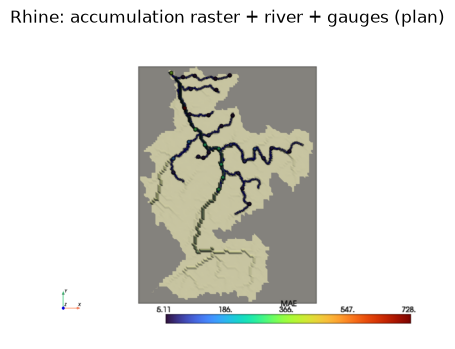

In [3]:
stems, tops, vals = lollipops(gauges, 'MAE', height=220_000.0, radius=5_000.0)
def build_scene(zexag):
    s = Scene3D(off_screen=True)
    s.terrain(acc, z_exaggeration=zexag, cmap='YlGnBu', show_scalar_bar=False)
    s.add_mesh(lines_to_tubes(river, radius=3_500.0, z=5_000.0), color='navy')
    s.add_mesh(stems, color='dimgray')
    s.point_cloud(tops, values=vals, point_size=24.0, cmap='turbo',
                  scalar_bar_args={'title': 'MAE'})
    s.plotter.add_axes()
    return s
scene = build_scene(zexag=6.0)
show(scene, 'Rhine: accumulation raster + river + gauges (plan)', view='top', parallel=True)
scene.close()

## The same scene, obliquely

From an oblique angle the gauge lollipops and river stand above the draped raster, showing the third dimension carries gauge MAE while the surface carries flow accumulation.

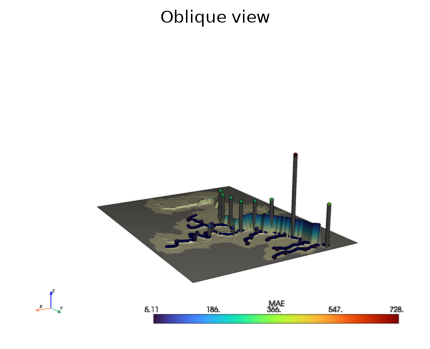

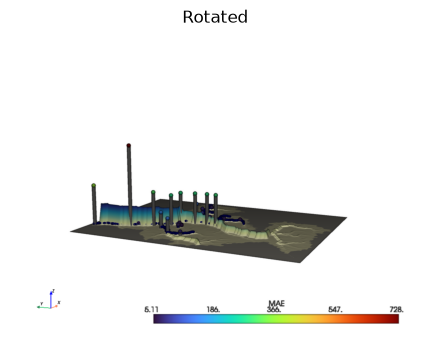

In [4]:
scene = build_scene(zexag=12.0)
show(scene, 'Oblique view', view=(15, -20))
show(scene, 'Rotated', view=(160, -25))
scene.close()

## An orbit fly-through

Sweep the camera around the whole GIS scene and write a GIF (to a temp dir, so there's no repo artifact).

orbit GIF bytes: 505863


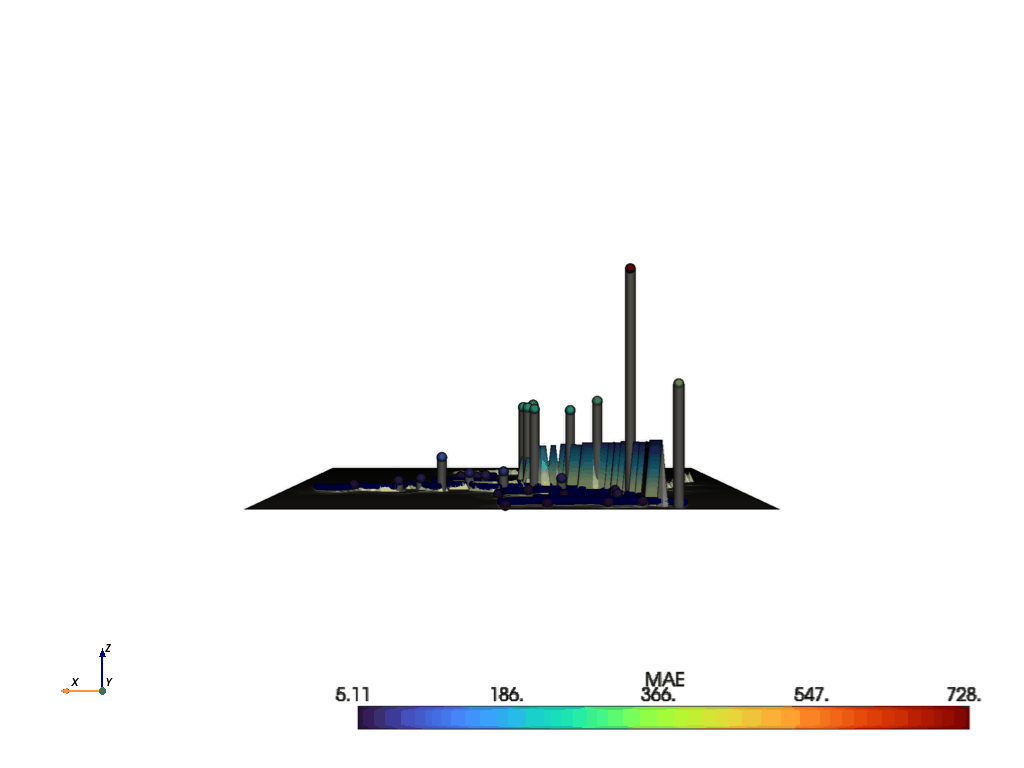

In [5]:
import tempfile, os
from IPython.display import Image as IPyImage, display
scene = build_scene(zexag=12.0)
scene.plotter.view_isometric()
gif = str(Path(tempfile.mkdtemp()) / 'rhine_orbit.gif')
scene.orbit(gif, n_frames=18, framerate=12)
scene.close()
print('orbit GIF bytes:', os.path.getsize(gif))
display(IPyImage(filename=gif))